# Model Development

## Purpose of This Notebook

This notebook focuses on **model development**, where multiple machine learning models are trained and compared to find the best model for prediction.

The goal is not only to train one model, but to compare several models and select the best-performing one using proper evaluation metrics.

This is an important part of the AI project because it demonstrates real machine learning decision-making.

## 1. Import Required Libraries

In this step, we import the libraries needed for model training and evaluation.

### These Libraries Help With

- Loading the dataset
- Splitting training and testing data
- Training machine learning models
- Calculating model performance scores
- Creating comparison charts
- Saving the best trained model

This prepares the notebook for machine learning model development.

In [1]:
# 1. IMPORT REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

warnings.filterwarnings("ignore")

plt.style.use("default")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Feature Engineered Dataset

We load the dataset created in Notebook 02: `final_feature_engineered_dataset.csv`.

### This Dataset Already Contains

- Cleaned data
- Encoded values
- Lag features
- Rolling features
- Selected important features

This is the final dataset used for model training.

In [2]:
# 2. LOAD FEATURE ENGINEERED DATASET

file_path = "../data/processed/final_feature_engineered_dataset.csv"

df = pd.read_csv(file_path)

print("Feature engineered dataset loaded successfully")

print(f"Total Rows: {df.shape[0]}")

print(f"Total Columns: {df.shape[1]}")

df.head()

Feature engineered dataset loaded successfully
Total Rows: 2371
Total Columns: 22


,date,product_id,product_name,category,unit_price,quantity_sold,revenue,month,day_of_week,day,year,week_of_year,is_weekend,rolling_avg_qty,previous_qty,calculated_revenue,lag_1,lag_2,rolling_avg_7,rolling_avg_30,category_encoded,product_encoded
0,2025-01-01,E001,13A Plug base (ACL),Electrical,650,11,7150,1,2,1,2025,1,0,11.000000,0.0,7150,0.0,0.0,11.000000,11.000000,0,0
1,2025-01-02,E001,13A Plug base (ACL),Electrical,650,6,3900,1,3,2,2025,1,0,8.500000,11.0,3900,11.0,0.0,8.500000,8.500000,0,0
2,2025-01-03,E001,13A Plug base (ACL),Electrical,650,8,5200,1,4,3,2025,1,0,8.333333,6.0,5200,6.0,11.0,8.333333,8.333333,0,0
3,2025-01-04,E001,13A Plug base (ACL),Electrical,650,11,7150,1,5,4,2025,1,1,8.333333,8.0,7150,8.0,6.0,9.000000,9.000000,0,0
4,2025-01-07,E001,13A Plug base (ACL),Electrical,650,18,11700,1,1,7,2025,2,0,12.333333,11.0,11700,11.0,8.0,10.800000,10.800000,0,0


## 3. Select Features and Target

We separate the dataset into input features and the target value.

### Features (`X`)

These are the input values used for prediction.

Examples:

- `unit_price`
- `month`
- Rolling averages
- Lag values
- Encoded product ID

### Target (`y`)

This is the value we want to predict.

In this notebook, the target is `quantity_sold`, which is used for demand prediction.

This step tells the model what to learn.

In [3]:
# 3. SELECT FEATURES AND TARGET

feature_columns = [
    "product_encoded",
    "category_encoded",
    "unit_price",
    "month",
    "day",
    "day_of_week",
    "is_weekend",
    "rolling_avg_qty",
    "previous_qty",
    "lag_1",
    "lag_2",
    "rolling_avg_7",
    "rolling_avg_30"

]

X = df[feature_columns]

# Target for Demand Prediction

y = df["quantity_sold"]

print("Features and target selected successfully")

Features and target selected successfully


## 4. Train Test Split

We divide the dataset into two parts.

### Training Data

Used to teach the model patterns.

### Testing Data

Used to check how well the model performs on new, unseen data.

### Split Ratio

- 80% for training
- 20% for testing

This is a standard machine learning practice.

In [4]:
# 4. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

print("Train-test split completed")

Train-test split completed


## 5. Define Models

We create multiple machine learning models for comparison.

### Models Used

- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Each model learns differently. Comparing multiple models helps us choose the best one and is stronger than relying on a single model.

In [5]:
# 5. DEFINE MODELS

models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(

        n_estimators=100,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )

}

print("Models initialized successfully")

Models initialized successfully


## 6. Train and Evaluate Models

Each model is trained using the training data, then predictions are made using the testing data.

### Evaluation Metrics

- `MAE`
- `MSE`
- `RMSE`
- `R2 Score`

These scores help measure model quality and form the core of model development.

In [6]:
# 6. TRAIN + EVALUATE MODELS

results = []

for model_name, model in models.items():

    print(f"Training: {model_name}")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    results.append({

        "Model": model_name,

        "MAE": round(mae, 2),

        "MSE": round(mse, 2),

        "RMSE": round(rmse, 2),

        "R2 Score": round(r2, 4)

    })

print("Model evaluation completed")

Training: Linear Regression
Training: Decision Tree
Training: Random Forest
Training: Gradient Boosting
Model evaluation completed


## 7. Results Table

All model scores are stored in a comparison table.

### Comparison Goals

Identify which model has:

- The lowest error
- The highest `R2 Score`

This makes the best model easy to identify and provides useful evidence for the final report.

In [7]:
# 7. RESULTS TABLE

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(

    by="R2 Score",

    ascending=False

)

print("\nModel Comparison Results:\n")

print(results_df)


Model Comparison Results:

               Model   MAE   MSE  RMSE  R2 Score
0  Linear Regression  0.53  1.36  1.17    0.9806
2      Random Forest  1.16  2.83  1.68    0.9597
3  Gradient Boosting  1.32  2.98  1.73    0.9575
1      Decision Tree  1.99  8.72  2.95    0.8759


## 8. Visualize Model Comparison

We create a bar chart using `R2 Score` to visually compare all models.

### This Helps With

- Presentations
- Viva explanations
- Final report screenshots

The chart improves both technical clarity and presentation quality.

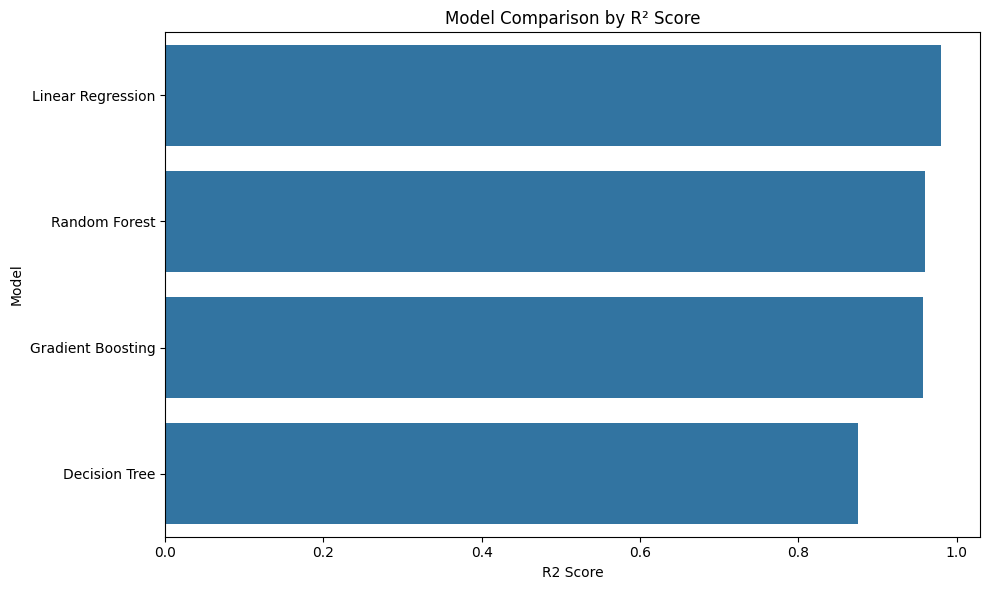

In [8]:
# 8. VISUALIZE MODEL COMPARISON

plt.figure(figsize=(10, 6))

sns.barplot(

    data=results_df,

    x="R2 Score",

    y="Model"

)

plt.title("Model Comparison by R² Score")

plt.tight_layout()

plt.show()

## 9. Save Results Report

We save the model comparison table as `model_scores.csv`.

### This Report Is Used In

- Final documentation
- Validation notebook
- Presentation slides

Saving the report keeps the project professional and organized.

In [9]:
# 9. SAVE RESULTS REPORT

results_df.to_csv(

    "../reports/model_scores.csv",

    index=False

)

print("Model scores report saved successfully")

Model scores report saved successfully


## 10. Save Best Model

The best-performing model is selected automatically, usually based on the highest `R2 Score`.

We save this model using `joblib`.

### Saved Model Usage

- Prediction API
- Backend integration
- Frontend prediction dashboard

This completes the production-ready machine learning workflow for demand prediction.

In [10]:
# 10. SAVE BEST MODEL

best_model_name = results_df.iloc[0]["Model"]

print(f"Best Performing Model: {best_model_name}")

best_model = models[best_model_name]

best_model.fit(X_train, y_train)

joblib.dump(

    best_model,

    "../models/best_demand_prediction_model.pkl"

)

print("Best model saved successfully")

Best Performing Model: Linear Regression
Best model saved successfully


## 11. Revenue Forecast Model

After completing the demand prediction model, we build the revenue forecast model.

### Prediction Goal

Predict future sales revenue.

### Business Benefits

- Monthly revenue planning
- Profit estimation
- Financial forecasting
- Business growth decisions

Instead of predicting product demand, this model focuses on predicting the total revenue generated from sales.

In [11]:
# 11. SELECT TARGET FOR REVENUE FORECASTING AND TRAIN TEST SPLIT

y_revenue = df["revenue"]

print("Revenue target selected successfully")


X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_revenue,

    test_size=0.20,

    random_state=42

)

print("Train-test split completed for revenue model")

Revenue target selected successfully
Train-test split completed for revenue model


## 12. Train Revenue Models

We train multiple machine learning models to compare revenue forecasting performance.

### Models Used

- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Each model predicts revenue differently. Testing multiple models helps identify the best-performing option instead of relying on only one model.

In [12]:
# 12. TRAIN + EVALUATE REVENUE MODELS

revenue_results = []

for model_name, model in models.items():

    print(f"Training Revenue Model: {model_name}")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    mse = mean_squared_error(y_test, predictions)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, predictions)

    revenue_results.append({

        "Model": model_name,

        "MAE": round(mae, 2),

        "MSE": round(mse, 2),

        "RMSE": round(rmse, 2),

        "R2 Score": round(r2, 4)

    })

print("Revenue model evaluation completed")

Training Revenue Model: Linear Regression
Training Revenue Model: Decision Tree
Training Revenue Model: Random Forest
Training Revenue Model: Gradient Boosting
Revenue model evaluation completed


## 13. Evaluate Revenue Models

Each revenue model is evaluated using standard regression metrics.

### Evaluation Metrics

- `MAE`
- `MSE`
- `RMSE`
- `R2 Score`

### These Scores Measure

- Prediction accuracy
- Error level
- Model reliability

The best model is usually the one with the lowest error and highest `R2 Score`, making model selection professional and data-driven.

In [13]:
# 13. REVENUE MODEL RESULTS TABLE

revenue_results_df = pd.DataFrame(revenue_results)

revenue_results_df = revenue_results_df.sort_values(

    by="R2 Score",

    ascending=False

)

print("\nRevenue Model Comparison Results:\n")

print(revenue_results_df)


Revenue Model Comparison Results:

               Model      MAE         MSE     RMSE  R2 Score
2      Random Forest   793.91  1623955.63  1274.35    0.9246
3  Gradient Boosting  1010.84  1985238.55  1408.98    0.9079
1      Decision Tree   998.66  2804533.84  1674.67    0.8699
0  Linear Regression  1963.28  6385334.37  2526.92    0.7037


## 14. Revenue Model Comparison Table

All revenue model scores are stored in a comparison table.

### This Table Is Useful For

- Final report
- Presentation
- Viva explanation

It clearly shows why one revenue model is selected over the others.

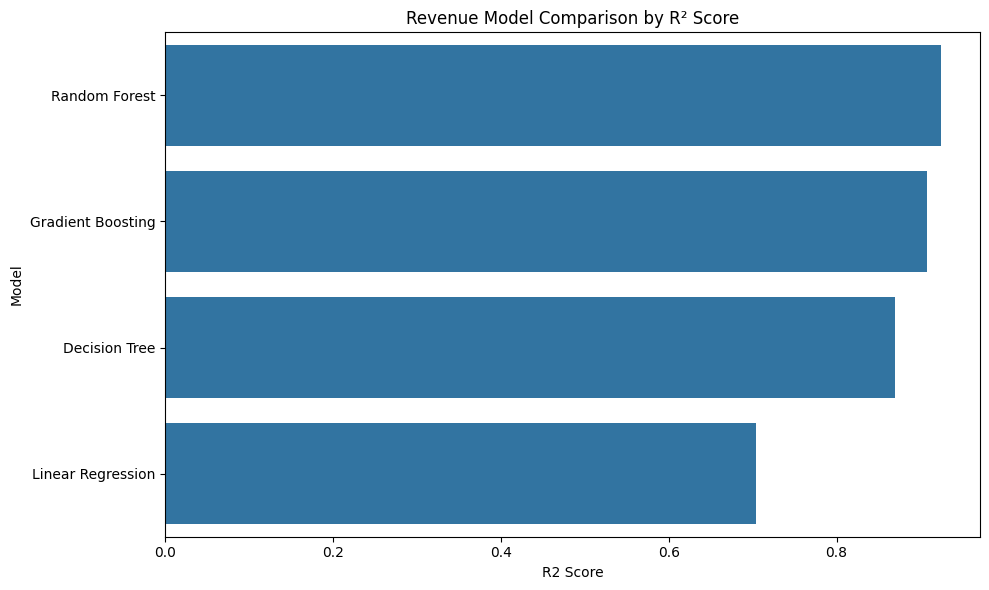

In [14]:
# 14. VISUALIZE REVENUE MODEL COMPARISON

plt.figure(figsize=(10, 6))

sns.barplot(

    data=revenue_results_df,

    x="R2 Score",

    y="Model"

)

plt.title("Revenue Model Comparison by R² Score")

plt.tight_layout()

plt.show()

## 15. Save Best Revenue Model

The best-performing revenue model is selected automatically and saved using `joblib`.

### Saved File

`best_revenue_forecast_model.pkl`

### Saved Model Usage

- Backend API
- Frontend dashboard
- Real-time revenue prediction

This completes the production-ready forecasting pipeline.

In [15]:
# 15. SAVE THE BEST REVENUE MODEL AND REPORT

revenue_results_df.to_csv(

    "../reports/revenue_model_scores.csv",

    index=False

)

print("Revenue model report saved successfully")


# SAVE BEST REVENUE MODEL

best_revenue_model_name = revenue_results_df.iloc[0]["Model"]

print(f"Best Revenue Model: {best_revenue_model_name}")

best_revenue_model = models[best_revenue_model_name]

best_revenue_model.fit(X_train, y_train)

joblib.dump(

    best_revenue_model,

    "../models/best_revenue_forecast_model.pkl"

)

print("Best revenue model saved successfully")

Revenue model report saved successfully
Best Revenue Model: Random Forest
Best revenue model saved successfully


## 16. Hyperparameter Tuning for Demand and Revenue Models

After comparing multiple machine learning models, the next step is to improve the best-performing models using **hyperparameter tuning**.

Hyperparameter tuning means adjusting model settings to achieve better prediction accuracy and stronger model performance. Instead of using default model settings, we search for the best combination of parameters.

### Why Hyperparameter Tuning Helps

- Improves prediction accuracy
- Improves model stability
- Improves `R2 Score`
- Reduces `RMSE`
- Strengthens overall forecasting quality

This is a professional machine learning practice and adds strong academic value to the project.

### Why We Use Random Forest

From the model comparison results, Random Forest performed strongly for both:

- Demand prediction
- Revenue forecasting

Random Forest is suitable for tuning because:

- It supports powerful optimization
- It performs well for business forecasting tasks
- It is widely trusted in academic and industry projects

### Parameters We Tune

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

These parameters control how the model learns patterns from the data. Finding the best values improves forecasting performance.

### GridSearchCV

We use `GridSearchCV` from Scikit-Learn to automatically test multiple parameter combinations and select the best one based on model performance.

### Demand Model Tuning

We first tune the Random Forest model for demand prediction.

**Target:** `quantity_sold`

This helps improve:

- Stock planning
- Inventory forecasting
- Product demand prediction

The best tuned model is saved as `tuned_demand_random_forest.pkl`.

### Revenue Model Tuning

Next, we tune the Random Forest model for revenue forecasting.

**Target:** `revenue`

This helps improve:

- Financial planning
- Monthly revenue forecasting
- Profit estimation

The best tuned model is saved as `tuned_revenue_random_forest.pkl`.

### Final Outcome

After hyperparameter tuning, we achieve:

- Better prediction accuracy
- Improved cross-validation scores
- Optimized machine learning models
- A stronger production-ready forecasting system

In [16]:
from sklearn.model_selection import GridSearchCV

In [18]:

#  DEFINE PARAMETER GRID
param_grid = {

    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]

}

print("Parameter grid created successfully")

Parameter grid created successfully


In [19]:
#  INITIALIZE BASE MODEL


rf_model = RandomForestRegressor(
    random_state=42
)

print("Base Random Forest model initialized")

Base Random Forest model initialized


In [20]:
#  APPLY GRID SEARCH

grid_search = GridSearchCV(

    estimator=rf_model,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=1

)

grid_search.fit(X_train, y_train)

print("Grid Search completed successfully")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Grid Search completed successfully


In [21]:
# BEST PARAMETERS

print("\nBest Parameters Found:\n")

print(grid_search.best_params_)

print(f"\nBest Cross Validation Score: {grid_search.best_score_:.4f}")


Best Parameters Found:

{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation Score: 0.9078


In [22]:
#  BEST TUNED MODEL

best_tuned_model = grid_search.best_estimator_

predictions = best_tuned_model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, predictions)

print("\nTuned Model Performance:\n")

print(f"MAE: {mae:.2f}")

print(f"MSE: {mse:.2f}")

print(f"RMSE: {rmse:.2f}")

print(f"R² Score: {r2:.4f}")


Tuned Model Performance:

MAE: 792.52
MSE: 1638495.93
RMSE: 1280.04
R² Score: 0.9240


In [23]:
#  SAVE TUNED MODEL

joblib.dump(

    best_tuned_model,

    "../models/tuned_random_forest_model.pkl"

)

print("Tuned Random Forest model saved successfully")

Tuned Random Forest model saved successfully


## 17. Hyperparameter Tuning for Demand Model

This section applies hyperparameter tuning to the demand prediction model using `quantity_sold` as the target variable.

In [24]:
# PREPARE DEMAND DATA

y_demand = df["quantity_sold"]

X_train_demand, X_test_demand, y_train_demand, y_test_demand = train_test_split(

    X,

    y_demand,

    test_size=0.20,

    random_state=42

)

print("Demand dataset prepared successfully")

Demand dataset prepared successfully


In [25]:
#  DEFINE PARAMETER GRID

param_grid = {

    "n_estimators": [100, 200],

    "max_depth": [10, 20, None],

    "min_samples_split": [2, 5],

    "min_samples_leaf": [1, 2]

}

print("Parameter grid created successfully")

Parameter grid created successfully


In [26]:
#  APPLY GRID SEARCH FOR DEMAND MODEL


rf_demand = RandomForestRegressor(random_state=42)

grid_search_demand = GridSearchCV(

    estimator=rf_demand,

    param_grid=param_grid,

    cv=3,

    scoring="r2",

    n_jobs=-1,

    verbose=1

)

grid_search_demand.fit(X_train_demand, y_train_demand)

print("Demand model Grid Search completed")

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Demand model Grid Search completed


In [27]:
#  BEST PARAMETERS — DEMAND MODEL

print("\nBest Parameters for Demand Model:\n")

print(grid_search_demand.best_params_)

print(

    f"\nBest Cross Validation Score: "

    f"{grid_search_demand.best_score_:.4f}"

)


Best Parameters for Demand Model:

{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross Validation Score: 0.9423


In [28]:
# EVALUATE TUNED DEMAND MODEL

best_tuned_demand_model = grid_search_demand.best_estimator_

predictions = best_tuned_demand_model.predict(X_test_demand)

mae = mean_absolute_error(y_test_demand, predictions)

mse = mean_squared_error(y_test_demand, predictions)

rmse = np.sqrt(mse)

r2 = r2_score(y_test_demand, predictions)

print("\nTuned Demand Model Performance:\n")

print(f"MAE: {mae:.2f}")

print(f"MSE: {mse:.2f}")

print(f"RMSE: {rmse:.2f}")

print(f"R² Score: {r2:.4f}")


Tuned Demand Model Performance:

MAE: 1.16
MSE: 2.83
RMSE: 1.68
R² Score: 0.9597


In [29]:
# SAVE TUNED DEMAND MODEL

joblib.dump(

    best_tuned_demand_model,

    "../models/tuned_demand_random_forest.pkl"

)

print("Tuned Demand Random Forest model saved successfully")

Tuned Demand Random Forest model saved successfully
